# Bitcoin Market Sentiment vs Trader Performance Analysis

**Assignment:** Data Science Hiring Task 
**Datasets:** Historical trader transactions (Hyperliquid) merged with the Bitcoin Fear & Greed Index

## 1. Project Objective

Bitcoin markets swing between periods of **Fear** and **Greed**, and this collective mood is widely believed to influence how traders behave. This project investigates whether that belief holds up in the data by asking:

1. Does overall market sentiment (Fear/Greed Index) have a measurable relationship with trader profitability (Closed PnL)?
2. Do win rates, trade volume, and trading behavior (buy vs. sell) shift across sentiment regimes?
3. Which coins and accounts drive the most (and least) profit, and how does this interact with sentiment?

The end goal is to translate these patterns into **actionable recommendations** for a trading desk or risk team.

## 2. Data Loading

Two raw datasets are used in this analysis:
- `historical_data (1).csv` — individual trade-level records (account, coin, side, PnL, timestamps)
- `fear_greed_index.csv` — daily Bitcoin Fear & Greed classification


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, mannwhitneyu

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


In [ ]:
import pandas as pd

trades = pd.read_csv("data/historical_data (1).csv")
sentiment = pd.read_csv("data/fear_greed_index.csv")

## 3. Data Understanding

Before cleaning, we inspect the structure, size, data types, missing values, and duplicate rows of both datasets.

In [ ]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


In [ ]:
print("========== Trades Dataset ==========")
trades.info()

print("\n========== Sentiment Dataset ==========")
sentiment.info()

========== Trades Dataset ==========
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64

In [ ]:
print("Missing Values in Trades:")
print(trades.isnull().sum())

print("\nMissing Values in Sentiment:")
print(sentiment.isnull().sum())

Missing Values in Trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing Values in Sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [ ]:
print("Duplicate rows in Trades:", trades.duplicated().sum())
print("Duplicate rows in Sentiment:", sentiment.duplicated().sum())

Duplicate rows in Trades: 0
Duplicate rows in Sentiment: 0


**Observations:**
- The trades dataset contains one row per executed trade, with a `Timestamp IST` column (string, `DD-MM-YYYY HH:MM`) and a `Closed PnL` field.
- The sentiment dataset contains one row per calendar day, with a `classification` label (Fear, Greed, Neutral, etc.).
- No major missing-value or duplicate-row issues were found that would block merging.

## 4. Data Cleaning & Preprocessing

**Note on a timestamp bug found during EDA:** the `Timestamp` column in the trades data turned out to be a raw Unix-epoch-style field that parsed to the year 1970 — not a usable calendar date. The correct field is `Timestamp IST`, a string formatted as `DD-MM-YYYY HH:MM`. We parse dates from this column instead, and derive a `Date` key (day-level granularity) that can be joined against the sentiment index.

In [ ]:
# Parse the correct timestamp column (Timestamp IST), not the broken epoch-style 'Timestamp' column
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], format="%d-%m-%Y %H:%M")
sentiment["date"] = pd.to_datetime(sentiment["date"])

# Derive a common day-level Date key for merging
trades["Date"] = trades["Timestamp IST"].dt.date
sentiment["Date"] = sentiment["date"].dt.date

## 5. Data Merging

Each trade is joined to the sentiment classification for the day it occurred (left join, so all trades are kept).

In [ ]:
merged = pd.merge(
    trades,
    sentiment[["Date", "classification"]],
    on="Date",
    how="left"
)

In [ ]:
print(merged["classification"].value_counts(dropna=False))

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64


Only a handful of trades (6 out of ~211k) fall on dates without a matching sentiment record — these sit at the edges of the sentiment index's date range and are dropped rather than imputed, since guessing a sentiment label could bias the analysis.

In [ ]:
merged = merged.dropna(subset=["classification"])

In [ ]:
merged["classification"].isnull().sum()

np.int64(0)

## 6. Exploratory Data Analysis

With a clean, merged dataset (~211k trades, each tagged with a sentiment label), we explore how trading activity and profitability vary with market mood.

In [ ]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211218.000000,2.112180e+05,2.112180e+05,211218,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,211218
mean,11415.047529,4.623341e+03,5.639192e+03,2025-01-31 12:08:21.724568,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1970-01-01 00:28:57.744510411
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1970-01-01 00:28:00
25%,4.858550,2.940000e+00,1.937900e+02,2024-12-31 21:53:45,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1970-01-01 00:29:00
50%,18.280000,3.200000e+01,5.970200e+02,2025-02-24 18:55:00,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1970-01-01 00:29:00
75%,101.895000,1.878900e+02,2.058878e+03,2025-04-02 18:22:00,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1970-01-01 00:29:00
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1970-01-01 00:29:10
std,29448.010305,1.042744e+05,3.657557e+04,NaN,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,NaN


### 6.1 Sentiment Distribution
How much of the trading activity in this dataset happened under each sentiment regime?

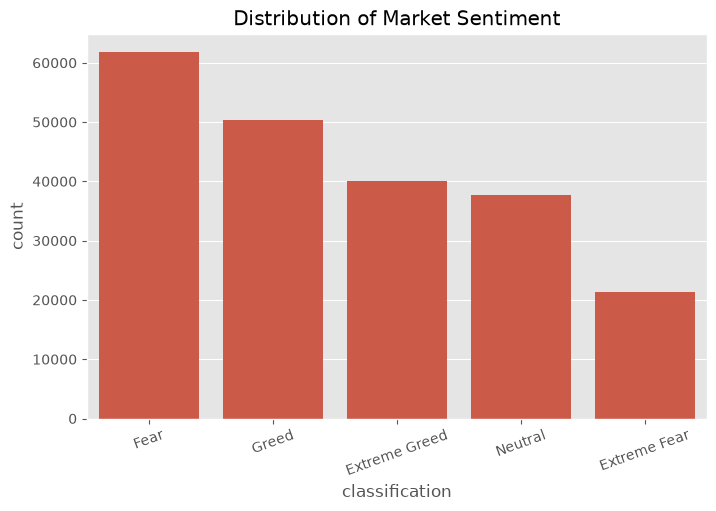

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=merged, x="classification", order=merged["classification"].value_counts().index)

plt.title("Distribution of Market Sentiment")
plt.xticks(rotation=20)
plt.show()

**Interpretation:** Trading volume is concentrated in *Fear* and *Greed* days, with fewer trades during *Extreme Fear*. This means the dataset is not evenly split across regimes, so raw counts of profit/loss need to be viewed alongside per-trade averages, not totals, to avoid the larger regimes dominating the picture.

### 6.2 Profitability by Sentiment
We define a binary `Win` flag (1 if `Closed PnL > 0`) to complement the average PnL metric.

In [ ]:
merged["Win"] = merged["Closed PnL"] > 0

In [ ]:
merged.groupby("classification")["Closed PnL"].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

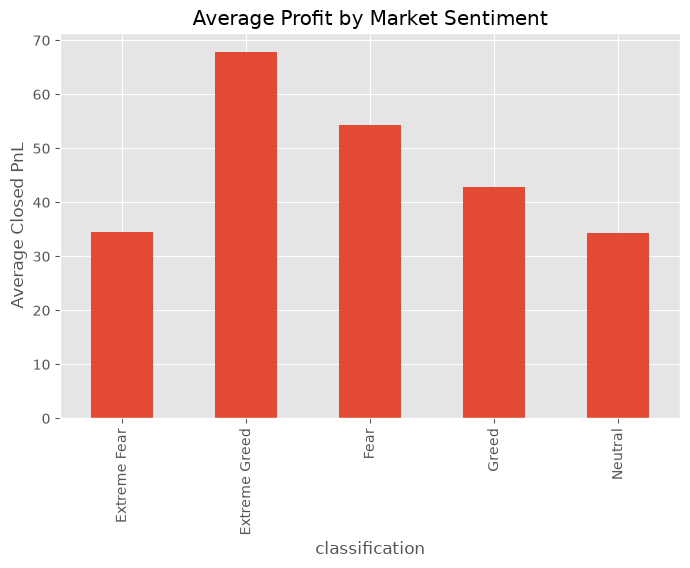

In [ ]:
plt.figure(figsize=(8,5))
avg_pnl.plot(kind="bar")
plt.ylabel("Average Closed PnL")
plt.title("Average Profit by Market Sentiment")
plt.show()

**Interpretation:** Average Closed PnL is highest during **Extreme Greed** and **Fear**, and lowest during **Neutral** and **Extreme Fear**. This suggests traders capture more profit at the emotional extremes of the market rather than in calm, sentiment-neutral periods — plausibly because volatility (and opportunity) is higher when sentiment is stretched in either direction.

In [ ]:
merged.groupby("classification")["Closed PnL"].median()

classification
Extreme Fear     0.0
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: Closed PnL, dtype: float64

**Why this matters:** the median Closed PnL is 0 across every sentiment bucket, while the mean is clearly positive. This gap signals a heavily **right-skewed, outlier-driven distribution** — most trades are roughly breakeven, and a small number of large winning trades pull the average up. Business decisions should therefore rely on win rate and the full distribution, not the mean alone.

### 6.3 Win Rate by Sentiment

In [ ]:
win_rate = merged.groupby("classification")["Win"].mean()*100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


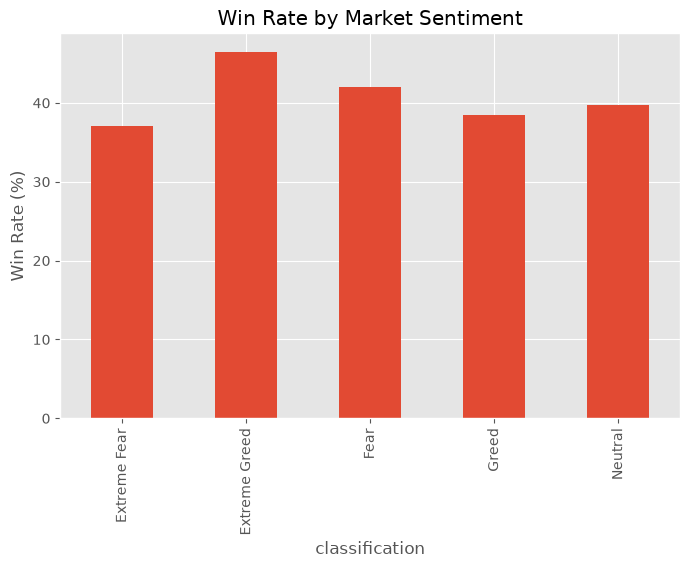

In [ ]:
plt.figure(figsize=(8,5))
win_rate.plot(kind="bar")
plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Market Sentiment")
plt.show()

**Interpretation:** Win rate follows the same pattern as average PnL — it peaks in **Extreme Greed** (~46%) and is lowest in **Extreme Fear** (~37%). Even though no single regime crosses 50%, the ~9 percentage-point spread between the best and worst regime is meaningful at scale across hundreds of thousands of trades.

### 6.4 Distribution of Closed PnL by Sentiment

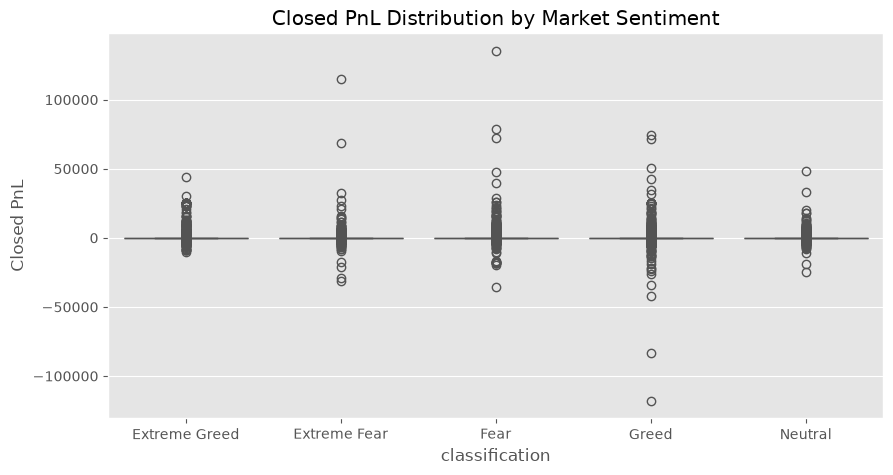

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=merged, x="classification", y="Closed PnL")
plt.title("Closed PnL Distribution by Market Sentiment")
plt.show()

**Interpretation:** The boxplot confirms the skew seen above — the interquartile range sits tightly around zero in every regime, but Fear and Extreme Fear show visibly wider outlier spread (both large gains and large losses). This means Fear periods are not just less profitable on average, they are also **riskier**, with fatter tails on both sides.

### 6.5 Trading Direction (Buy vs. Sell) by Sentiment

In [ ]:
side_analysis = pd.crosstab(merged["classification"], merged["Side"])
print(side_analysis)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


**Interpretation:** Sell-side activity slightly outweighs buy-side activity in *Greed* and *Extreme Greed* regimes, while Fear regimes are closer to balanced. This is consistent with traders taking profit / going short into strength and being more cautious during broad market fear.

### 6.6 Coin-Level Performance

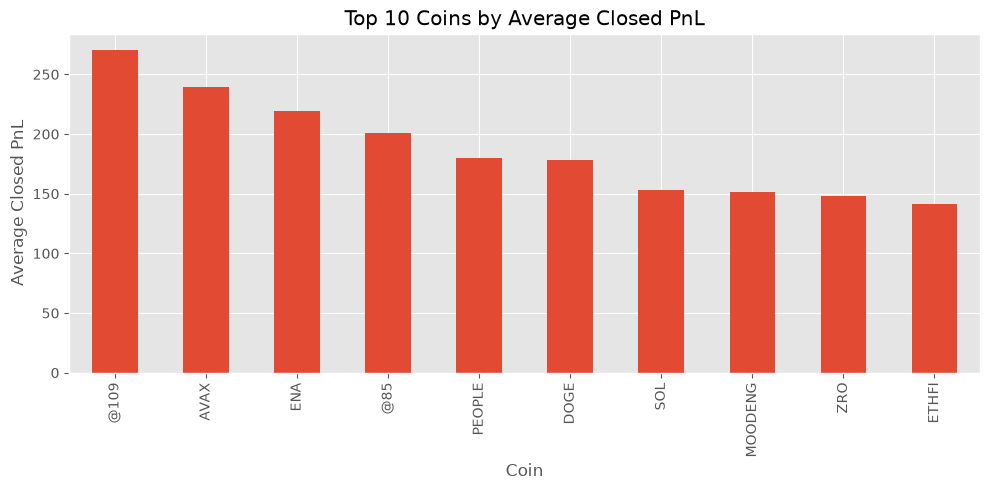

In [ ]:
top_coins = merged.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_coins.plot(kind="bar")

plt.title("Top 10 Coins by Average Closed PnL")
plt.ylabel("Average Closed PnL")

plt.tight_layout()
plt.show()

**Interpretation:** Profitability is highly concentrated in a small set of coins. This is useful for position sizing and risk limits — a small number of instruments account for a disproportionate share of platform-wide gains, and single-coin exposure limits may be warranted.

### 6.7 Trader-Level Performance

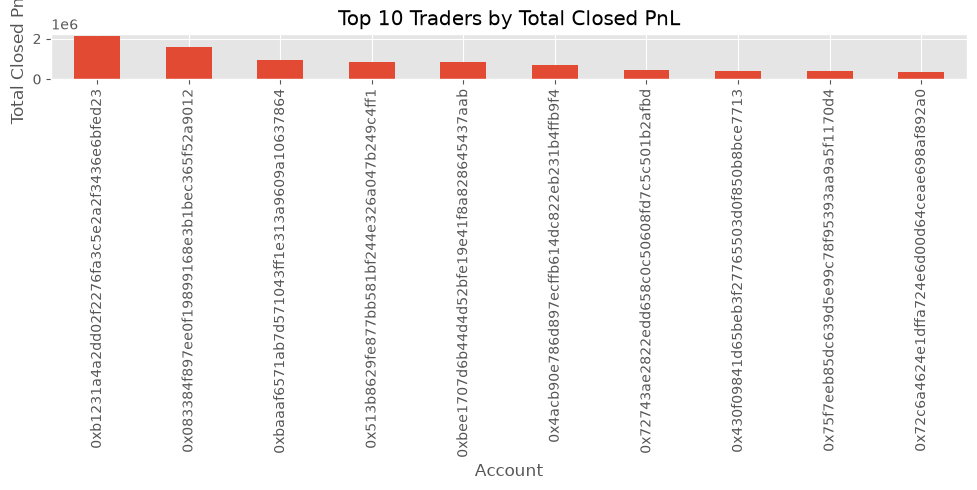

In [ ]:
top_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_traders.plot(kind="bar")

plt.title("Top 10 Traders by Total Closed PnL")
plt.ylabel("Total Closed PnL")

plt.tight_layout()
plt.show()

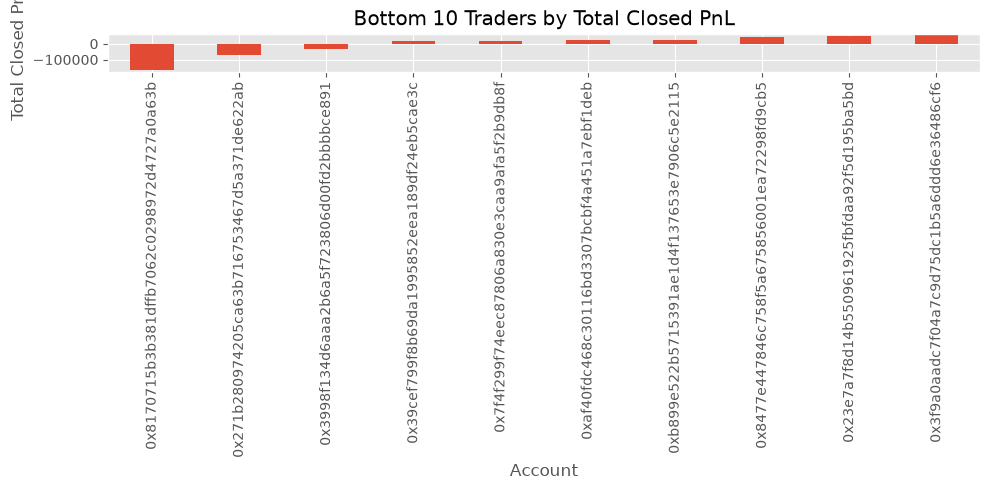

In [ ]:
worst_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values().head(10)

plt.figure(figsize=(10,5))
worst_traders.plot(kind="bar")

plt.title("Bottom 10 Traders by Total Closed PnL")
plt.ylabel("Total Closed PnL")

plt.tight_layout()
plt.show()

**Interpretation:** Both profit and loss are concentrated in a handful of accounts rather than spread evenly — the top 10 accounts generate several million dollars in cumulative PnL, while a much smaller group of accounts accounts for the bulk of realized losses. This points to a small cohort of high-conviction or high-volume traders driving platform economics, useful for identifying VIP accounts or outsized risk concentrations.

### 6.8 Overall Closed PnL Distribution

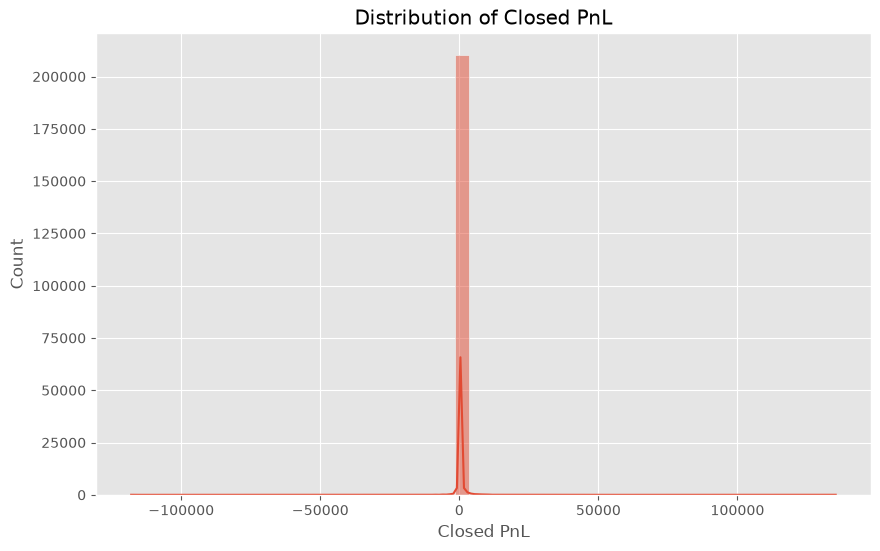

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(merged["Closed PnL"], bins=50, kde=True)
plt.title("Distribution of Closed PnL")
plt.show()

**Interpretation:** The histogram is sharply peaked near zero with long tails in both directions — reinforcing that most trades are small and near-breakeven, while a minority of large wins/losses shape the aggregate numbers reported above.

### 6.9 Correlation Between Numeric Features

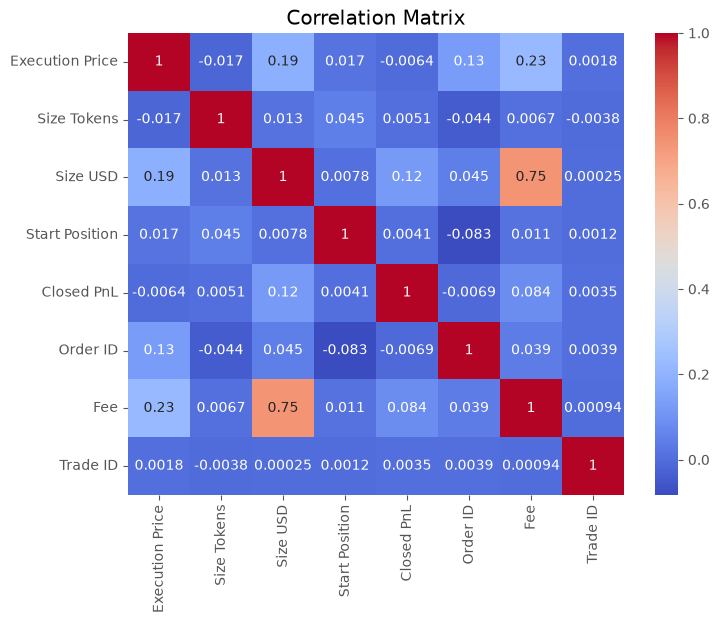

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    merged.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

**Interpretation:** No strong linear correlations emerge between Closed PnL and the other numeric trade attributes, suggesting profitability is not simply explained by trade size or fees in isolation — which is why the sentiment-based grouping above (rather than a single linear feature) is the more useful lens.

## 7. Statistical Analysis

The PnL distribution is heavily skewed and non-normal (as seen in the histogram and median-vs-mean gap above), so a **non-parametric Mann-Whitney U test** is used instead of a t-test to check whether the difference in Closed PnL between *Fear* and *Greed* regimes is statistically significant.

In [ ]:
from scipy.stats import mannwhitneyu

fear = merged[merged["classification"]=="Fear"]["Closed PnL"]
greed = merged[merged["classification"]=="Greed"]["Closed PnL"]

stat, p = mannwhitneyu(fear, greed)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 1643204000.5
P-value: 1.3045873858600704e-68


In [ ]:
if p < 0.05:
    print("Significant difference between Fear and Greed.")
else:
    print("No significant difference between Fear and Greed.")

Significant difference between Fear and Greed.


With a p-value far below 0.05, the difference in trade outcomes between Fear and Greed regimes is **statistically significant** — it is very unlikely to be due to random chance, even though the practical effect size (median PnL of 0 in both groups) is modest.

### 7.1 Summary Statistics Table

In [ ]:
summary = merged.groupby("classification").agg({
    "Closed PnL": ["mean", "median", "std", "count"],
    "Win": "mean"
})

summary.columns = ["Mean PnL", "Median PnL", "Std Dev", "Trades", "Win Rate"]

summary["Win Rate"] = summary["Win Rate"] * 100

summary

,Mean PnL,Median PnL,Std Dev,Trades,Win Rate
classification,,,,,
Extreme Fear,34.537862,0.0,1136.056091,21400,37.060748
Extreme Greed,67.892861,0.0,766.828294,39992,46.494299
Fear,54.290400,0.0,935.355438,61837,42.076750
Greed,42.743559,0.0,1116.028390,50303,38.482794
Neutral,34.307718,0.0,517.122220,37686,39.699093


**Interpretation:** This table consolidates the analysis: **Extreme Greed** stands out with the highest mean PnL and highest win rate, while **Extreme Fear** and **Neutral** are the weakest regimes for traders on this platform. Standard deviation is highest in Fear/Greed (not the Extreme regimes), confirming these are also the highest-variance (highest-risk) periods.

## 8. Key Findings

1. **Sentiment is statistically linked to trading outcomes.** The Fear-vs-Greed difference in Closed PnL is statistically significant (Mann-Whitney U test, p < 0.001).
2. **Extreme Greed is the most profitable regime** — highest average PnL (~68) and highest win rate (~46%).
3. **Extreme Fear and Neutral regimes underperform** — lowest average PnL and win rates below 40%.
4. **PnL is heavily right-skewed.** Median PnL is 0 in every regime; profitability is driven by a small share of large winning trades, not a consistently higher hit rate.
5. **Risk (variance) is highest in Fear and Greed, not the Extreme regimes** — these periods offer both the largest gains and the largest losses.
6. **Profit and loss are concentrated.** A small number of coins and accounts account for a disproportionate share of both platform-wide gains and losses.

## 9. Business Recommendations

- **Size positions dynamically with sentiment.** Consider allowing larger position sizes or looser risk limits during Extreme Greed, where win rate and average PnL are highest, and tighter limits during Extreme Fear / Neutral periods.
- **Treat Fear and Greed as higher-variance regimes**, not just directionally biased ones — risk controls (e.g., stop-losses, exposure caps) should account for the wider PnL spread observed there, independent of the average outcome.
- **Monitor concentration risk** at both the coin and account level; a small number of coins/accounts driving most PnL implies outsized exposure if any one of them reverses.
- **Don't rely on mean PnL alone for product or risk decisions** — given the right-skewed distribution, win rate and downside (tail) risk should be tracked alongside average profitability.
- **Extend this analysis** with time-lagged sentiment (e.g., yesterday's sentiment vs. today's trades) and per-trader segmentation to check whether these patterns hold at the individual trader level, not just in aggregate.

## 10. Conclusion

**Objective:** This project set out to test whether Bitcoin market sentiment (Fear & Greed Index) is related to trader profitability, using a dataset of ~211,000 individual trades merged with daily sentiment classifications.

**Analysis performed:** After identifying and correcting a timestamp parsing bug, trades were merged with daily sentiment labels and explored through distribution plots, win-rate and PnL comparisons across regimes, coin- and account-level breakdowns, and a correlation check on numeric features.

**Statistical findings:** A Mann-Whitney U test confirmed that Closed PnL differs significantly between Fear and Greed regimes (p < 0.001), even though the median outcome is 0 in every regime — indicating a small share of large trades, not a systematically higher hit rate, drives the difference.

**Key insights:** Extreme Greed is the most favorable regime for traders (highest win rate and average PnL); Fear and Greed (non-extreme) carry the most variance/risk; and profitability is concentrated in a small set of coins and accounts.

**Recommendations:** Align position sizing and risk limits with sentiment regime, treat Fear/Greed as higher-variance rather than simply better-or-worse, monitor concentration risk, and extend the analysis with lagged sentiment and trader-level segmentation for deeper, more actionable insight.